# **Spectral type pdf flagger part 1: star-PDF.**

In another script, we developped a PDFstar flagger which assumes the spectral type of a star by looking at the best fit of a onesource object over a star template. We used a 1 dimensional, and limited, sed lib which was to cover smoothly the entire specter of star spectral-types (from O to M and with a few white dwarves). 

Looking at the functionning of Lephare to determine photo-z, when we use the minimal Chi2 method, we determine the type of galaxy at a pecular redshift, so we fit a source to a 2D grid.

Aside that, there is three main quantities that determine the atmosphere of a star : Surface temperature (**Teff**), Mass or gravity (**log(g)**) and composition or metallicity (**Fe/H**).

Taking these informations into account, we can use the same logic as the one used to compute the photo-z of a source but to determine the spectral-type of a star. Hence, this time we want to use a more complete 2D or 3D grid of star sed.

Thus we pre-made a star sed library for Lephare that covers every knew type of star with those physical quantities, and run lephare onto it.

To works, it is important to have written the specs of the utilized seds either in the respective file name or in a commmented header. 

## **0. Initialisation**

In [4]:
### Libs ###
from imports import *

base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(base_dir)

# Custom libraries
import scripts.statsplot as ssp
import scripts.utils as sutils
%matplotlib inline

#--- Stats & Maths---
from scipy.stats import norm

## **1. The SED grid(s)**

Note: sed grids are not perfectly square or cubic: some simulated sed are unrealistic, for example it is unsual to see a O-type star with a low log(g). It would be a loss of time to compute the minimal Chi2 of a fit of a onesource to such a sed. Thus the sed grids are truncated at specific Teff values.

**Teff** vs **log(g)** vs **Fe/H**

In [5]:
#--- sed grid class ---

class SED_GRID:
    '''
    For a SED set dependent on physical parameters, construct a coherent grid.
    '''
    def __init__(self, list_path):
        """Load SED list."""
        sed_list = []
        with open(list_path, 'r') as file:
            for line in file:
                line = line.strip()
                if line.startswith('#') or not line:
                    continue
                filepath = line.split()[0]
                sp_type = filepath.split('/')[-1].replace('.sed', "")
                sed_list.append(sp_type)
        self.sed_list = sed_list
        self.sed_grid = None

    def build(self):
        """Build the sed grid [Id, Teff, logg, FeH] from filenames."""
        pattern = r"Teff([-\d\.]+)_logg([-\d\.]+)_FeH([-\d\.]+)"
        sed_grid = []
        for Id, s in enumerate(self.sed_list):
            match = re.search(pattern, s)
            if match:
                Teff, logg, FeH = match.groups()
                Teff, logg, FeH = float(Teff), float(logg), float(FeH)
                sed_grid.append([Id, Teff, logg, FeH])
        self.sed_grid = np.array(sed_grid)
        return self.sed_grid

    def plot(self, cmap='gnuplot'):
        """Plot 3D SED grid with color depending on FeH."""
        if self.sed_grid is None:
            raise ValueError("Call make_sed_grid before plot.")

        Teff, logg, FeH = self.sed_grid[:, 1], self.sed_grid[:, 2], self.sed_grid[:, 3]

        fig = plt.figure(figsize=(7, 5))
        ax = fig.add_subplot(projection='3d')

        # Couleur selon la métallicité
        sc = ax.scatter(Teff, logg, FeH,
            c=FeH, cmap=cmap,
            alpha=0.8, s=10, edgecolor="none")

        # Colorbar
        cbar = plt.colorbar(sc, ax=ax, pad=0.1, shrink=0.8)
        cbar.set_label('[Fe/H]', rotation=270, labelpad=15)

        ax.set_xlabel('Teff [K]')
        ax.set_ylabel('log(g)')
        ax.set_zlabel('[Fe/H]')
        ax.set_title("SED Grid Colored by Metallicity")

        # Optionnel : meilleure orientation par défaut
        ax.view_init(elev=20, azim=-45)

        plt.tight_layout()
        plt.show()

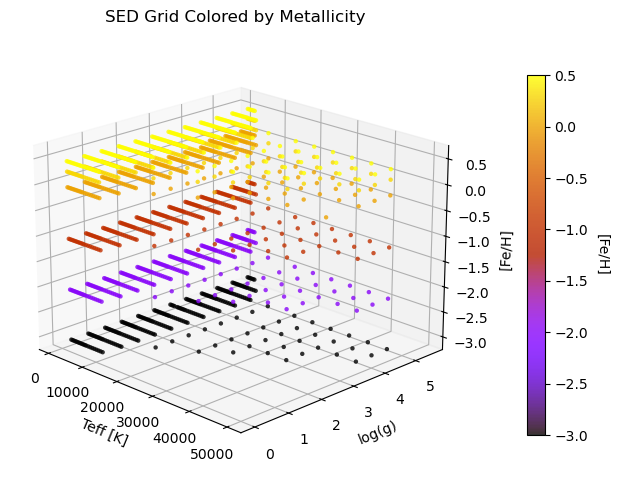

In [6]:
# %matplotlib widget
sed_grid_path = f'{base_dir}/simulated_sed/bt_spectra/bt_star_sed_full.list'
sed_grid_init = SED_GRID(sed_grid_path)
sed_grid = sed_grid_init.build()
sed_grid_init.plot()

## **2. Build $\chi²$ grids & PDFs**

During its processing, the only way to identify which template(s) has been used to compute the quantities relative to a onesource it's their Id. This Id is assigned when creating the sed library (with the SedLib part of the code), and is useful to retrieve the sed during or at the end of the process. 

A notable difference between the PDZ and the star-PDF is that the first one is computed from a grid that has been created thanks to the MagLab part of the code, while the star-PDF will be made from a already full 2D or 3D grid. Which means that we need to "remember" the Id of each seds to re-order them in the good way to have a smooth functionning PDF.



So first we need functions to retrieve the physical quanities relative to a sed (**Teff**, **log(g)** and **Fe/H**) thanks to its Id.

In [7]:
from mpl_toolkits.mplot3d import Axes3D
import re

class STAR_PDF:
    def __init__(self, sed_grid):
        if sed_grid is None:
            raise ValueError("SED_GRID: call sed_grid_obj.build() before using STAR_PDF.")

        self.sed_grid = sed_grid   # base grid
        self.len_sed_grid = len(self.sed_grid)
        self.chi2_grid = None

    
    def build_chi2_grid(self, chi2_array):
        """Attach chi2 array to SED grid."""
        if len(chi2_array) != self.len_sed_grid:
            raise ValueError("chi2 array length does not match sed_grid length.")

        self.chi2_grid = np.column_stack((self.sed_grid, chi2_array))
        return self.chi2_grid

    
    def project_min_chi2(self, xaxis="Teff", yaxis=None, to_prob=False, fixed=None):
        """
        Project Chi² parallel to one or two axes.
        Uses self.chi2_grid automatically.
        """
        if self.chi2_grid is None:
            raise ValueError("Call build_chi2_grid before projecting.")

        grid = self.chi2_grid
        columns = ["Id", "Teff", "logg", "FeH", "Chi2"]
        col_idx = {k: i for i, k in enumerate(columns)}

        # 1) Apply fixed filters
        mask = np.ones(len(grid), dtype=bool)
        if fixed:
            for key, val in fixed.items():
                mask &= np.isclose(grid[:, col_idx[key]], val)
            grid = grid[mask]
            if len(grid) == 0:
                raise ValueError("No grid point matches the given fixed conditions.")

        xcol = col_idx[xaxis]

        if yaxis:   # ----------- 2D PROJECTION -------------
            ycol = col_idx[yaxis]

            X_vals = np.unique(grid[:, xcol])
            Y_vals = np.unique(grid[:, ycol])
            Z = np.full((len(Y_vals), len(X_vals)), np.nan)

            for i, xv in enumerate(X_vals):
                for j, yv in enumerate(Y_vals):
                    mask_xy = np.isclose(grid[:, xcol], xv) & np.isclose(grid[:, ycol], yv)
                    if np.any(mask_xy):
                        Z[j, i] = np.nanmin(grid[mask_xy, -1])

            if to_prob:
                Zmin = np.nanmin(Z)
                Z = np.exp(-0.5 * (Z - Zmin))

            return X_vals, Y_vals, Z

        else:       # ----------- 1D PROJECTION -------------
            X_vals = np.unique(grid[:, xcol])
            Z = np.full(len(X_vals), np.nan)

            for i, xv in enumerate(X_vals):
                mask_x = np.isclose(grid[:, xcol], xv)
                if np.any(mask_x):
                    Z[i] = np.nanmin(grid[mask_x, -1])

            if to_prob:
                Zmin = np.nanmin(Z)
                Z = np.exp(-0.5 * (Z - Zmin))

            return X_vals, Z

    
    def plot_min_chi2(self, xaxis="Teff", yaxis=None, to_prob=False,
                      full=False, cmap='gnuplot', fixed=None):

        if self.chi2_grid is None:
            raise ValueError("Call build_chi2_grid before plotting.")

        grid = self.chi2_grid  # just to avoid rewriting this everywhere

        # --- FULL CORNER-PLOT ---
        if full:
            axes = ["Teff", "logg", "FeH"]
            n = len(axes)

            # Uniform axes
            limits = {}
            for ax in axes:
                limits[ax] = np.unique(grid[:, {"Teff": 1, "logg": 2, "FeH": 3}[ax]])
            
            fig = plt.figure(figsize=(8, 8))
            gs = plt.GridSpec(n, n, wspace=0.0, hspace=0.0)

            for i in range(n):  # line
                for j in range(n):  # col
                    if j > i:
                        continue
                    ax = fig.add_subplot(gs[i, j])

                    if i == j:
                        # --- PDF 1D ---
                        X, Z = self.project_min_chi2(xaxis=axes[j], to_prob=to_prob, fixed=fixed)
                        ax.plot(X, Z, color='black', lw=1)
                        # ax.fill_between(X, Z, color='C0', alpha=0.4)
                        ax.set_xlim(limits[axes[j]].min(), limits[axes[j]].max())
                        ax.set_ylim(Z.min() * 0.95, Z.max() * 1.05)
                        if i < n - 1:
                            ax.set_xticklabels([])
                        if i != 0:
                            ax.yaxis.tick_right()
                        else:
                            ax.set_xlabel(axes[j])

                    else:
                        # --- PDF 2D ---
                        X, Y, Z = self.project_min_chi2(xaxis=axes[j], yaxis=axes[i], fixed=fixed)
                        if to_prob:
                            Z = np.exp(-0.5 * (Z - np.nanmin(Z)))
                        im = ax.pcolormesh(X, Y, Z, shading='auto', cmap=cmap)
                        ax.set_xlim(limits[axes[j]].min(), limits[axes[j]].max())
                        ax.set_ylim(limits[axes[i]].min(), limits[axes[i]].max())
                        if i < n - 1:
                            ax.set_xticklabels([])
                        else:
                            ax.set_xlabel(axes[j])
                        if j > 0:
                            ax.set_yticklabels([])
                        else:
                            ax.set_ylabel(axes[i])

            # Colorbar
            cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])
            cbar = fig.colorbar(im, cax=cbar_ax)
            cbar.set_label("Probability" if to_prob else "min(χ²)")
            plt.subplots_adjust(left=0.08, right=0.9, top=0.9, bottom=0.08)
            plt.show()
            return


        # --- Single plot mode
        if yaxis:
            X, Y, Z = self.project_min_chi2(xaxis, yaxis, to_prob=to_prob, fixed=fixed)
            plt.figure(figsize=(6, 4))
            plt.pcolormesh(X, Y, Z, shading='auto')
            plt.colorbar(label="Probability" if to_prob else "min(Chi²)")
            plt.xlabel(xaxis)
            plt.ylabel(yaxis)
            plt.title(f"Minimized Chi² map")
            plt.show()
        else:
            X, Z = self.project_min_chi2(xaxis, to_prob=to_prob, fixed=fixed)
            plt.figure(figsize=(6, 3))
            plt.plot(X, Z, marker='o', lw=1)
            plt.xlabel(xaxis)
            plt.ylabel("Probability" if to_prob else "min(Chi²)")
            plt.title("Minimized Chi² PDF")
            plt.grid(True)
            plt.show()

    
    def plot_full_chi2(self, cmap='gnuplot'):
        """Plot 3D SED grid with color depending on FeH."""
        grid = self.chi2_grid  # just to avoid rewriting this everywhere
        Teff, logg, FeH = grid[:, 1], grid[:, 2], grid[:, 3]
        Chi2 = grid[:, 4]
        fig = plt.figure(figsize=(7, 5))
        ax = fig.add_subplot(projection='3d')
        # Coulor as a function of Chi2
        sc = ax.scatter(
            Teff, logg, FeH,
            c=Chi2, cmap=cmap,
            alpha=0.8, s=10, edgecolor="none"
        )

        # Colorbar
        cbar = plt.colorbar(sc, ax=ax, pad=0.1, shrink=0.8)
        cbar.set_label('Chi2', rotation=270, labelpad=15)

        ax.set_xlabel('Teff [K]')
        ax.set_ylabel('log(g)')
        ax.set_zlabel('[Fe/H]')
        ax.set_title("SED Grid Colored by Metallicity")
 
        # Optionnel : meilleure orientation par défaut
        ax.view_init(elev=20, azim=-45)
 
        plt.tight_layout()
        plt.show()

    
    def best_output(self):
        grid = self.chi2_grid
        best_sed_id = np.argmin(grid[:,4])
        chi2_best = min(grid[:,4])
        Teff_best = grid[best_sed_id, 1]
        logg_best = grid[best_sed_id, 2]
        FeH_best = grid[best_sed_id, 3]
        
        chisec_grid = np.delete(grid, best_sed_id, axis=0)
        sec_best_sed_id = np.argmin(chisec_grid[:,4])
        sec_chi2_best = min(chisec_grid[:,4])
        sec_Teff_best = chisec_grid[sec_best_sed_id, 1]
        sec_logg_best = chisec_grid[sec_best_sed_id, 2]
        sec_FeH_best = chisec_grid[sec_best_sed_id, 3]
        sec_best_sed_id = sec_best_sed_id + 1 if sec_best_sed_id >= best_sed_id else sec_best_sed_id
        return [best_sed_id, Teff_best, logg_best, FeH_best, chi2_best, 
                sec_best_sed_id, sec_Teff_best, sec_logg_best, sec_FeH_best, sec_chi2_best]

### PDF example

In [8]:
chi2_values_path = f"{base_dir}/catalogs/DC2/dp02_dc2_62_BT_LSST_full_PDFstar.prob"
chi2_values = np.loadtxt(chi2_values_path, max_rows=1000)

/tmp/ipykernel_18532/758861816.py:2: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=1000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  chi2_values = np.loadtxt(chi2_values_path, max_rows=1000)


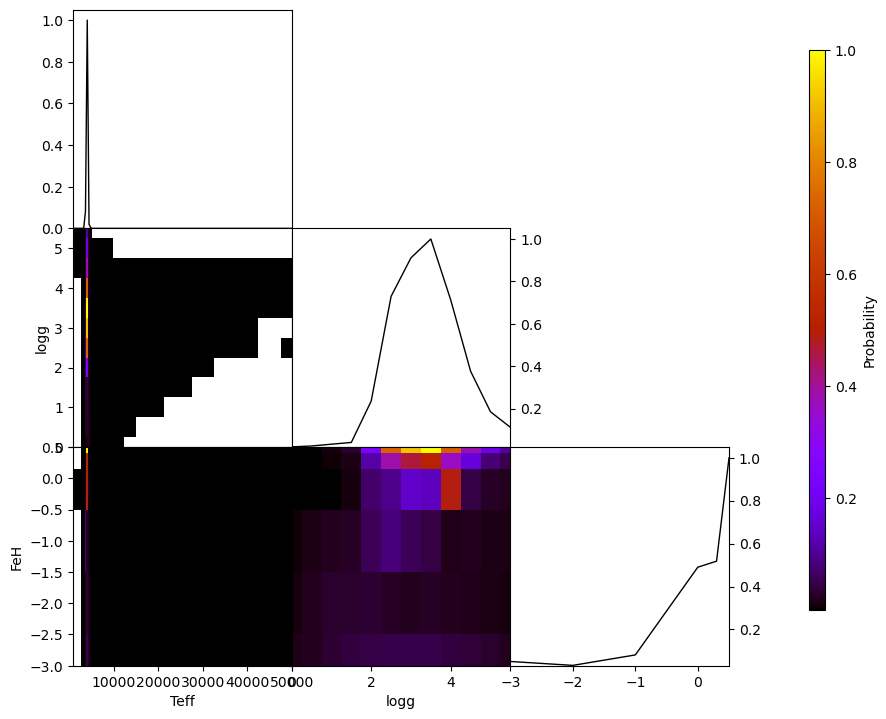

In [234]:
star_pdf = STAR_PDF(sed_grid)
chi2_grid = star_pdf.build_chi2_grid(chi2_values[89,1:])
star_pdf.plot_min_chi2(to_prob=True, full=True)#, fixed={"FeH": 0.5, "Teff": 7200})

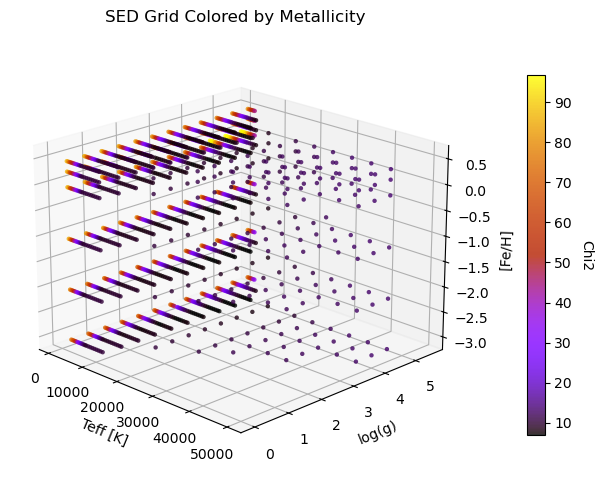

In [10]:
%matplotlib inline
star_pdf.plot_full_chi2()

## **3. PDF Analyzer - Computing statistical quantities describing the PDFs of onesource**

Now that we obtained the PDFs (or Chi2 distribution) of every sources that passed through Lephare, we're getting close to build a classifier.

Looking at the precedent results, we clearly see visual differences between star "starPDF" and galaxy "starPDF", the first ones generally looking better than the other. Thus we need to turn this visual results into statistical tools to make our binarry classifier.

### 3.1 The STAR_PDF_ANALYZER class is constitued as follow:

 - **Preliminary functions:** _init_, _make_prob3d, _project_1d, project_2d ;
 - **1D PDF analysis functions:** npeaks1D, peak_ratio_1D, std_1D ;
 - **2D PDF analysis functions:** cov_2d, area_highprob_2d ;
 - **global PDF analysis functions:** entropy, concentration, delta_chi2 ;
 - **compute_all_features** 

 These functions are typical statistical tools for PDF, we will identify later which ones are the most relevant.

In [11]:
from scipy.signal import find_peaks
from scipy.interpolate import interp1d, griddata, RegularGridInterpolator
from scipy.ndimage import gaussian_filter
from numba import njit

class STAR_PDF_ANALYZER:
    """
    Analyzer for chi2_grid (Nx5 array: [Id, Teff, logg, FeH, Chi2]).
    Option A: interpolation is done on chi2 (not on probabilities).
    - to_prob_3D: if True, compute global P3 (full-grid PDF) once at init
    - to_prob: if True, projectors return normalized probabilities per projection
    """
    def __init__(self, chi2_grid, to_prob=True, to_prob_3D=False,
                oversample=1.0, nmax=800):

        chi2_grid = np.asarray(chi2_grid)
        if chi2_grid.ndim != 2 or chi2_grid.shape[1] < 5:
            raise ValueError("chi2_grid must be shape (N,>=5)")

        self.grid = chi2_grid
        self.to_prob = bool(to_prob)
        self.to_prob_3D = bool(to_prob_3D)

        self.col = {"Id": 0, "Teff": 1, "logg": 2, "FeH": 3, "Chi2": 4}

        # precomputation
        self.axis_vals = {}
        self.axis_idx = {}

        for ax in ["Teff", "logg", "FeH"]:
            vals = np.unique(self.grid[:, self.col[ax]])
            vals.sort()
            self.axis_vals[ax] = vals

            # map grid values -> integer indices
            idx = np.searchsorted(vals, self.grid[:, self.col[ax]])
            self.axis_idx[ax] = idx.astype(np.int32)

        self._proj1d_cache = {}
        self._proj2d_cache = {}

        # global chi2
        chi2 = self.grid[:, self.col["Chi2"]]
        self.chi2_min_global = float(np.nanmin(chi2))

        self.P3 = None
        if self.to_prob_3D:
            self._make_prob3d()

        self._regular_cache = {}
        self._oversample = float(oversample)
        self._nmax = int(nmax)

    # --------------------------
    # Internal helpers: PDFs
    # --------------------------
    def _build_fixed_mask(self, fixed):
        if not fixed:
            return np.ones(len(self.grid), dtype=bool)

        mask = np.ones(len(self.grid), dtype=bool)
        for ax, val in fixed.items():
            i = np.where(np.isclose(self.axis_vals[ax], val))[0]
            if len(i) == 0:
                return np.zeros(len(self.grid), dtype=bool)
            mask &= (self.axis_idx[ax] == i[0])
        return mask

    def _make_prob3d(self):
        """Compute full-grid probability P3 normalized."""
        chi2 = self.grid[:, self.col["Chi2"]].astype(float)
        dchi2 = chi2 - np.nanmin(chi2)
        with np.errstate(over="ignore", invalid="ignore"):
            P = np.exp(-0.5 * dchi2)
        P[np.isnan(P)] = 0.0
        s = P.sum()
        if s <= 0:
            P = np.zeros_like(P)
        else:
            P = P / s
        self.P3 = P
        return P
    
    # --------------------------
    # Regular grid utilities
    # --------------------------
    def _unique_sorted_axis(self, axis):
        vals = np.unique(self.grid[:, self.col[axis]])
        vals = np.sort(vals)
        return vals

    def _is_regular_axis(self, vals, rtol=1e-8):
        """Return True if axis values are regularly spaced (within rtol)."""
        if vals.size < 3:
            return True
        d = np.diff(vals)
        # consider only positive diffs
        dpos = d[d > 0]
        if dpos.size == 0:
            return True
        return np.allclose(dpos, dpos[0], rtol=rtol, atol=0)

    def _optimal_regular_grid(self, vals):
        """Build regular grid using dx = min positive difference (pas minimum observed)."""
        vals = np.sort(np.unique(vals))
        if vals.size < 2:
            return vals.copy()
        d = np.diff(vals)
        dpos = d[d > 0]
        if dpos.size == 0:
            return vals.copy()
        dx_min = float(np.min(dpos))
        xmin, xmax = float(vals[0]), float(vals[-1])
        # number of steps based on dx_min and oversampling factor
        n = int(np.ceil(self._oversample * (xmax - xmin) / dx_min)) + 1
        n = max(2, min(n, self._nmax))
        grid = np.linspace(xmin, xmax, n)
        return grid

    def _get_regular_axis(self, axis):
        """Return cached regular grid for axis or build it. Also return flag regular."""
        if axis in self._regular_cache:
            return self._regular_cache[axis]["vals"], self._regular_cache[axis]["regular"]

        vals = self._unique_sorted_axis(axis)
        regular = self._is_regular_axis(vals)
        if regular:
            grid = vals.copy()
        else:
            grid = self._optimal_regular_grid(vals)
        self._regular_cache[axis] = {"vals": grid, "regular": regular}
        return grid, regular

    # --------------------------
    # Regularize (interpolate) 1D and 2D on chi2 then convert if needed
    # --------------------------
    def _regularize_1d_chi2(self, X, P, axis):
        good = ~np.isnan(P)
        if not np.any(good):
            return np.array([]), np.array([])

        Xg = X[good]
        Pg = P[good]

        grid, is_reg = self._get_regular_axis(axis)

        f = interp1d(Xg, Pg, bounds_error=False, fill_value=np.nan)
        return grid, f(grid)

    def _regularize_2d_chi2(self, X, Y, P, xaxis, yaxis):
        Xr, _ = self._get_regular_axis(xaxis)
        Yr, _ = self._get_regular_axis(yaxis)

        # interpolation séparable (beaucoup plus rapide que griddata)
        Px = np.array([
            np.interp(Xr, X, row, left=np.nan, right=np.nan)
            for row in P
        ])

        Pr = np.array([
            np.interp(Yr, Y, Px[:, i], left=np.nan, right=np.nan)
            for i in range(len(Xr))
        ]).T

        return Xr, Yr, Pr

    # --------------------------
    # Projection on original grid (min chi2 over other dims)
    # --------------------------
    def _project_min_chi2_1d_raw(self, axis, fixed=None):
        idx = self.axis_idx[axis]
        chi2 = self.grid[:, self.col["Chi2"]]

        mask = self._build_fixed_mask(fixed)
        idx = idx[mask]
        chi2 = chi2[mask]

        n = len(self.axis_vals[axis])
        out = np.full(n, np.inf)
        np.minimum.at(out, idx, chi2)

        out[out == np.inf] = np.nan
        return self.axis_vals[axis], out

    def _project_min_chi2_2d_raw(self, xaxis, yaxis, fixed=None):
        xi = self.axis_idx[xaxis]
        yi = self.axis_idx[yaxis]
        chi2 = self.grid[:, self.col["Chi2"]]

        mask = self._build_fixed_mask(fixed)
        xi = xi[mask]
        yi = yi[mask]
        chi2 = chi2[mask]

        nx = len(self.axis_vals[xaxis])
        ny = len(self.axis_vals[yaxis])

        P = np.full((ny, nx), np.inf)
        np.minimum.at(P, (yi, xi), chi2)

        P[P == np.inf] = np.nan
        return self.axis_vals[xaxis], self.axis_vals[yaxis], P

    # --------------------------
    # Public projectors that return either chi2 or probability on regularized grid
    # --------------------------
    def project_1d(self, axis, to_prob=None, fixed=None):
        """
        Return Xr, P where:
         - Xr: regularized axis grid
         - P: if to_prob True -> normalized probability (sum=1); else -> chi2 (min chi2 per X)
        """
        key = (axis, bool(to_prob), None if fixed is None else tuple(sorted(fixed.items())))
        if key in self._proj1d_cache:
            return self._proj1d_cache[key]
        if to_prob is None:
            to_prob = self.to_prob

        Xraw, Pchi2_raw = self._project_min_chi2_1d_raw(axis, fixed=fixed)
        if Xraw.size == 0:
            return np.array([]), np.array([])

        Xr, Pchi2 = self._regularize_1d_chi2(Xraw, Pchi2_raw, axis)

        if Xr.size == 0:
            return np.array([]), np.array([])

        if to_prob:
            # convert chi2 -> probability with local minimum
            if np.all(np.isnan(Pchi2)):
                return Xr, np.zeros_like(Pchi2)
            dchi = Pchi2 - np.nanmin(Pchi2)
            with np.errstate(over="ignore", invalid="ignore"):
                P = np.exp(-0.5 * dchi)
            P[np.isnan(P)] = 0.0
            s = np.nansum(P)
            if s > 0:
                P = P / s
            else:
                P = np.zeros_like(P)
            self._proj1d_cache[key] = (Xr, P)
            return Xr, P
        else:
            self._proj1d_cache[key] = (Xr, P)
            return Xr, Pchi2

    def project_2d(self, xaxis, yaxis, to_prob=None, fixed=None):
        """
        Return Xr, Yr, P where:
         - Xr, Yr: regularized axis grids
         - P: if to_prob True -> normalized probability (sum ~1); else -> chi2 map (min chi2 per cell)
        """
        key = (xaxis, yaxis, bool(to_prob), None if fixed is None else tuple(sorted(fixed.items())))
        if key in self._proj2d_cache:
            return self._proj2d_cache[key]
        if to_prob is None:
            to_prob = self.to_prob

        Xraw, Yraw, Pchi2_raw = self._project_min_chi2_2d_raw(xaxis, yaxis, fixed=fixed)
        if Xraw.size == 0 or Yraw.size == 0:
            return np.array([]), np.array([]), np.array([[]])

        Xr, Yr, Pchi2 = self._regularize_2d_chi2(Xraw, Yraw, Pchi2_raw, xaxis, yaxis)

        if Xr.size == 0 or Yr.size == 0:
            return np.array([]), np.array([]), np.array([[]])

        if to_prob:
            if np.all(np.isnan(Pchi2)):
                return Xr, Yr, np.zeros_like(Pchi2)
            dchi = Pchi2 - np.nanmin(Pchi2)
            with np.errstate(over="ignore", invalid="ignore"):
                P = np.exp(-0.5 * dchi)
            P[np.isnan(P)] = 0.0
            s = np.nansum(P)
            if s > 0:
                P = P / s
            else:
                P = np.zeros_like(P)
            self._proj2d_cache[key] = (Xr, Yr, P)
            return Xr, Yr, P
        else:
            self._proj2d_cache[key] = (Xr, Yr, P)
            return Xr, Yr, Pchi2

    # --------------------------
    # Metrics (1D)
    # --------------------------
    def npeaks_1d(self, axis, threshold=0.2, fixed=None):
        _, P = self.project_1d(axis, to_prob=self.to_prob, fixed=fixed)
        if P.size == 0:
            return -99

        arr = P if self.to_prob else -P
        m = np.nanmax(arr)
        if not np.isfinite(m) or m <= 0:
            return 0

        peaks, _ = find_peaks(arr, height=threshold * m)
        return int(peaks.size)

    def peakratio_1d(self, axis, fixed=None):
        _, P = self.project_1d(axis, to_prob=self.to_prob, fixed=fixed)
        if P.size == 0:
            return -99

        mx = np.nanmax(P)
        return float(np.nanmean(P) / mx) if mx > 0 else -99

    def std_1d(self, axis, fixed=None):
        X, P = self.project_1d(axis, to_prob=self.to_prob, fixed=fixed)
        if P.size == 0:
            return -99

        if self.to_prob:
            W = P
        else:
            dchi = P - np.nanmin(P)
            W = np.exp(-0.5 * dchi)
            W[~np.isfinite(W)] = 0.0

        s = W.sum()
        if s <= 0:
            return -99
        W /= s
        mu = np.sum(X * W)
        return float(np.sqrt(np.sum(W * (X - mu) ** 2)))

    # --------------------------
    # Metrics (2D)
    # --------------------------
    def cov_2d(self, xaxis, yaxis, fixed=None):
        X, Y, P = self.project_2d(xaxis, yaxis, to_prob=True, fixed=fixed)
        if P.size == 0:
            return (-99, -99, -99, -99)

        # adapt proba to the regularized grid
        dx = np.gradient(X)
        dy = np.gradient(Y)
        DX, DY = np.meshgrid(dx, dy)
        W = P * DX * DY

        tot = W.sum()
        if tot <= 0:
            return (-99, -99, -99, -99)
        # make prob grid
        W /= tot
        Xg, Yg = np.meshgrid(X, Y)

        # Compute covariances
        mx = np.sum(W * Xg)
        my = np.sum(W * Yg)

        cov_xx = np.sum(W * (Xg - mx) ** 2)
        cov_yy = np.sum(W * (Yg - my) ** 2)
        cov_xy = np.sum(W * (Xg - mx) * (Yg - my))

        cov_mat = np.array([[cov_xx, cov_xy],
                            [cov_xy, cov_yy]])

        eig = np.linalg.eigvalsh(cov_mat)
        eig = np.maximum(eig, 1e-300)
        axis_ratio = float(np.sqrt(eig[1] / eig[0]))

        return float(cov_xx), float(cov_yy), float(cov_xy), axis_ratio

    def area_highprob_2d(self, xaxis, yaxis, threshold=0.5, fixed=None):
        X, Y, P = self.project_2d(xaxis, yaxis, to_prob=True, fixed=fixed)
        if P.size == 0:
            return -99.0

        Pmax = np.nanmax(P)
        if Pmax <= 0:
            return 0.0
        # adapt proba to the regularized grid
        dx = np.gradient(X)
        dy = np.gradient(Y)
        DX, DY = np.meshgrid(dx, dy)
        A = DX * DY
        
        valid = np.isfinite(P)
        high = P >= threshold * Pmax

        Atot = np.sum(A[valid])
        if Atot <= 0:
            return -99.0

        return float(np.sum(A[high & valid]) / Atot)

    # --------------------------
    # Global metrics
    # --------------------------
    def entropy(self):
        if self.P3 is None:
            # if P3 not precomputed, compute from chi2 on the fly
            self._make_prob3d()
        P = np.array(self.P3, dtype=float)
        mask = P > 0
        if np.sum(mask) == 0:
            return -99.0
        H = -np.sum(P[mask] * np.log(P[mask]))
        return float(H)

    def concentration(self, delta_chi2=1.0):
        chi2 = self.grid[:, self.col["Chi2"]].astype(float)
        if self.P3 is None:
            self._make_prob3d()
        mask = chi2 <= (self.chi2_min_global + float(delta_chi2))
        if np.sum(mask) == 0:
            return 0.0
        return float(np.sum(self.P3[mask]))

    def delta_chi2(self):
        chi2 = np.array(self.grid[:, self.col["Chi2"]], dtype=float)
        if chi2.size < 2:
            return -99.0
        sorted_chi = np.sort(chi2)
        return float(sorted_chi[1] - sorted_chi[0])

    # --------------------------
    # Main entry: compute all features
    # --------------------------
    def compute_all(self, fixed=None):
        """
        Compute all requested features and return as dict.
        fixed: optional dict to restrict projection (e.g. {"FeH":0.0})
        """
        feats = {}

        for ax in ["Teff", "logg", "FeH"]:
            feats[f"npeaks_{ax}"] = self.npeaks_1d(ax, threshold=0.2, fixed=fixed)
            feats[f"peakratio_{ax}"] = self.peakratio_1d(ax, fixed=fixed)
            feats[f"std_{ax}"] = self.std_1d(ax, fixed=fixed)

        pairs = [("Teff", "logg"), ("Teff", "FeH"), ("logg", "FeH")]
        for x, y in pairs:
            cov_xx, cov_yy, cov_xy, axis_ratio = self.cov_2d(x, y, fixed=fixed)
            feats[f"cov_{x}_{y}_xx"] = cov_xx
            feats[f"cov_{x}_{y}_yy"] = cov_yy
            feats[f"cov_{x}_{y}_xy"] = cov_xy
            feats[f"axisratio_{x}_{y}"] = axis_ratio
            feats[f"area_{x}_{y}_p50"] = self.area_highprob_2d(x, y, threshold=0.5, fixed=fixed)
            feats[f"area_{x}_{y}_p90"] = self.area_highprob_2d(x, y, threshold=0.9, fixed=fixed)

        feats["entropy"] = self.entropy()
        feats["concentration_dchi2_1"] = self.concentration(delta_chi2=1.0)
        feats["delta_chi2"] = self.delta_chi2()
        return feats



In [12]:
# Testing the class
import time
program_starts = time.time()
star_pdf_analyzer = STAR_PDF_ANALYZER(chi2_grid)
star_pdf_features = star_pdf_analyzer.compute_all()
star_pdf_features
print(time.time()- program_starts)

0.0039463043212890625


### 3.2 Sample analyzer

In [51]:
from joblib import Parallel, delayed

class SAMPLE_ANALYZER:
    def __init__(self, chi2_path, sed_grid_path, nrows=None, n_jobs=1):

        # --- Load raw file as strings ---
        raw = pd.read_csv(chi2_path, sep=r"\s+", header=None,
                        dtype="str", comment="#", nrows=nrows)
        raw = raw.to_numpy()
        self.ids = raw[:, 0].astype(np.int64)
        self.chi2_values = raw[:, 1:].astype(float)

        # SED grid (constant for all sources)
        self.sed_grid_obj = SED_GRID(sed_grid_path)
        self.sed_grid = self.sed_grid_obj.build()

        self.n_jobs = int(n_jobs)

    def best_fit_distribution(self, n_rows=None):

        star_pdf = STAR_PDF(self.sed_grid)
        data = []

        N = n_rows if n_rows is not None else len(self.ids)

        for i in range(N):
            _ = star_pdf.build_chi2_grid(self.chi2_values[i])
            df = star_pdf.best_output()
            data.append([self.ids[i]] + df)

        columns = ['source_id',
            'best_sed_id', 'Teff_best', 'logg_best', 'FeH_best', 'chi2_best',
            'sec_best_sed_id', 'sec_Teff_best', 'sec_logg_best', 'sec_FeH_best', 'sec_chi2_best']

        self.sample_df = pd.DataFrame(data, columns=columns)
        return self.sample_df

    def stat_feature_distribution(self, n_rows=None):

        N = n_rows if n_rows is not None else len(self.ids)
        star_pdf = STAR_PDF(self.sed_grid)

        # ---- worker function 
        def onesource(i):
            chi2_grid = star_pdf.build_chi2_grid(self.chi2_values[i])
            analyzer = STAR_PDF_ANALYZER(chi2_grid)
            feats = analyzer.compute_all()
            feats["source_id"] = self.ids[i]
            return feats

        # ---- run
        if self.n_jobs == 1:
            rows = [onesource(i) for i in range(N)]
        else:
            rows = Parallel(n_jobs=self.n_jobs, backend="loky")(
                delayed(onesource)(i) for i in range(N))

        # ---- build dataframe with fixed column order
        columns = ["source_id"] + [k for k in rows[0].keys() if k != "source_id"]
        self.feature_df = pd.DataFrame(rows, columns=columns)

        return self.feature_df


    def plot_best(self, axis='chi2_best'):
        plt.figure()
        plt.hist(self.sample_df[axis].values, bins=50)
        plt.xlabel(axis)
        plt.ylabel("N")
        plt.show()


In [ ]:
#--- Init the class ---
chi2_values_path = f"{base_dir}/catalogs/DC2/dp02_dc2_62_BT_LSST_full_PDFstar.prob"
sample_analyzer = SAMPLE_ANALYZER(chi2_values_path, sed_grid_path, nrows=1000000)

# chi2_values_path = f"{base_dir}/simulation_catalogs/DC2/trilegal_dc2_errors_BT_LSST_full_PDFstar.prob"
# sample_analyzer = SAMPLE_ANALYZER(chi2_values_path, sed_grid_path, nrows=1000000)

In [ ]:
#--- Compute statistics ---
training_sample_features = sample_analyzer.stat_feature_distribution()
# training_sample_features.to_csv(f'{base_dir}/catalogs/DC2/dc2_stats_features.csv', index=False)

### 3.3 Compute the statistical features

In [ ]:
best_fit_distribution = sample_analyzer.best_fit_distribution()
# best_fit_distribution.to_csv(f'{base_dir}/catalogs/DC2/dc2_best_physical_quantities.csv', index=False)

### 3.4 Merge the different table into one

We have three tables: one with the statistics, one with the physical parameters and the original table. Yet we can merge them into one, and use this final table to either use it for calibration, either classify the sources.

In [ ]:
dp02_dc2_62_table = pd.read_csv(f'{base_dir}/catalogs/DC2/dp02_dc2_62.csv')
#to not execute evrything again:
# training_sample_features = pd.read_csv(f'{base_dir}/catalogs/DC2/dc2_stats_features.csv')
# best_fit_distribution = pd.read_csv(f'{base_dir}/catalogs/DC2/dc2_best_physical_quantities.csv')

In [ ]:
training_sample = sutils.join_tables(training_sample_features, 
                [(dp02_dc2_62_table[['mt_match_objectId', 'ts_truth_type', 'umag', 'umag_err', 'gmag', 'gmag_err', #select only intersting columns
                        'rmag', 'rmag_err', 'imag', 'imag_err', 'zmag', 'zmag_err', 'ymag', 'ymag_err']], 'source_id', 'mt_match_objectId'), 
                (best_fit_distribution, 'source_id', 'source_id')], 
                how='left')

In [91]:
training_sample.to_csv(f'{base_dir}/catalogs/DC2/dc2_starpdf_features.csv', index=False)

In [37]:
training_sample[training_sample['ts_truth_type']==2][:3]

,source_id,npeaks_Teff,peakratio_Teff,std_Teff,npeaks_logg,peakratio_logg,std_logg,npeaks_FeH,peakratio_FeH,std_FeH,...,best_sed_id,Teff_best,logg_best,FeH_best,chi2_best,sec_best_sed_id,sec_Teff_best,sec_logg_best,sec_FeH_best,sec_chi2_best
0,1651413688361421449,1,0.028793,6.090667e+02,1,0.942599,1.690101e+00,0,0.727342,1.035656,...,907,4800.0,3.0,-3.0,5.5427,913,4800.0,3.5,-3.0,5.5451
1,1651413688361451863,1,0.008300,6.945617e+01,1,0.287778,7.460804e-01,1,0.151169,0.794221,...,755,4000.0,3.5,0.5,19.8090,749,4000.0,3.0,0.5,20.1420
193,1651413688361451488,1,0.008065,2.527686e-51,0,0.083333,5.427798e-08,1,0.052632,0.000026,...,1027,5600.0,0.0,-2.0,72.1960,1033,5600.0,0.5,-2.0,136.3400


## **4. Test on DP1**

### 4.1 Run star pdf algorithms

In [76]:
chi2_DP1_values_path = f'{base_dir}/catalogs/DP1/PDFs/DP1_buzzard_BT_LSST_full_PDFstar.prob"'
chi2_DP1_values = np.loadtxt(chi2_DP1_values_path, max_rows=100000)

/tmp/ipykernel_18532/772046229.py:2: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=100000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  chi2_DP1_values = np.loadtxt(chi2_DP1_values_path, max_rows=100000)


Build grid

In [ ]:
star_pdf_DP1 = STAR_PDF(sed_grid)
# chi2_grid_DP1 = star_pdf_DP1.build_chi2_grid(chi2_DP1_values[9,1:])
# star_pdf_DP1.plot_min_chi2(to_prob=True, full=True)#, fixed={"FeH": 0.5, "Teff": 7200})

Compute statisticals and physical properties

In [78]:
sample_analyzer_DP1 = SAMPLE_ANALYZER(chi2_DP1_values_path, sed_grid_path, nrows=100000)
training_sample_features_DP1 = sample_analyzer_DP1.stat_feature_distribution()

In [79]:
best_fit_distribution_DP1 = sample_analyzer_DP1.best_fit_distribution()

Concat in one table

In [ ]:
dp1ECDFS_stars = pd.read_csv(f'{base_dir}/catalogs/DP1/DP1_ECDFS_star_photometry.csv')

In [156]:
mask_nan = ((dp1ECDFS_stars['u_psfMag']) >0) & ((dp1ECDFS_stars['y_psfMag']) >0)
dp1ECDFS_stars = dp1ECDFS_stars[mask_nan]

In [ ]:
training_sample_DP1 = sutils.join_tables(training_sample_features_DP1, [(dp1ECDFS_stars[['objectId']], 'source_id', 'objectId')],
                                         indicator=True, drop_unmatched=False)

In [342]:
training_sample_DP1.to_csv(f'{base_dir}/catalogs/DP1/dp1_starpdf_features.csv', index=False)

### 4.2 Teff en FeH estimation efficiency

LePHARE can thus be used to determine physical properties of a star. Here is a comparison with the Ivezić et al. (2008, ApJ, 684, 287; Eq. 4) method.

In [151]:
intrinsic_property_tables = sutils.join_tables(dp1ECDFS_stars, [(best_fit_distribution_DP1, 'objectId', 'source_id')], how=('left'))

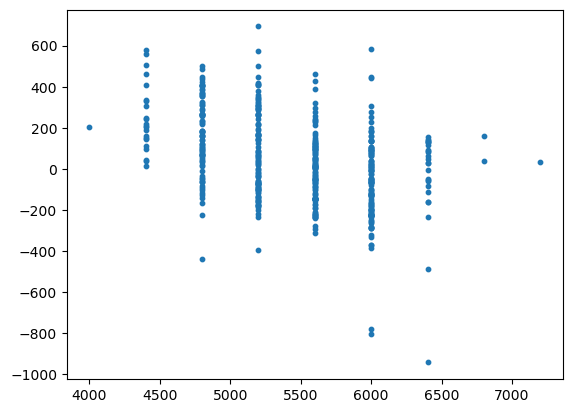

In [89]:
plt.figure()
plt.scatter(intrinsic_property_tables['Teff_best'], intrinsic_property_tables['Teff_best']-10**intrinsic_property_tables['log_teff'], s=10)
# plt.scatter(intrinsic_property_tables['FeH_best'], intrinsic_property_tables['FeH_best']-intrinsic_property_tables['feh'],s=10)
plt.show()

## **5. Test on Trilegal**

In [308]:
#--- Build grid ---
chi2_trilegal_values_path = f'{base_dir}/catalogs/DC2/trilegal_dc2_errors_BT_LSST_full_PDFstar.prob'
chi2_trilegal_values = np.loadtxt(chi2_trilegal_values_path, max_rows=100000)
star_pdf_trilegal = STAR_PDF(sed_grid)

#--- Compute statistics ---
sample_analyzer_trilegal = SAMPLE_ANALYZER(chi2_trilegal_values_path, sed_grid_path, nrows=100000)
training_sample_features_trilegal = sample_analyzer_trilegal.stat_feature_distribution()
#--- And physical properties
best_fit_distribution_trilegal = sample_analyzer_trilegal.best_fit_distribution()

/tmp/ipykernel_18532/4020046212.py:3: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=100000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  chi2_trilegal_values = np.loadtxt(chi2_trilegal_values_path, max_rows=100000)


In [336]:
#--- Merge ---
trilegal_cat = pd.read_csv(f'{base_dir}/catalogs/DC2/trilegal_stars_with_dc2_errors.csv')
training_sample_trilegal = sutils.join_tables(training_sample_features_trilegal, 
                [(best_fit_distribution_trilegal, 'source_id', 'source_id'),
                (trilegal_cat[['random_id', 'umag', 'umag_err_sim', 'gmag', 'gmag_err_sim', #select only intersting columns
                        'rmag', 'rmag_err_sim', 'imag', 'imag_err_sim', 'zmag', 'zmag_err_sim', 'ymag', 'ymag_err_sim',
                        'logte', 'logg', 'm_h']], 'source_id', 'random_id')], 
                how='left')

In [343]:
training_sample_trilegal.to_csv(f'{base_dir}/catalogs/DC2/trilegal_starpdf_features.csv', index=False)

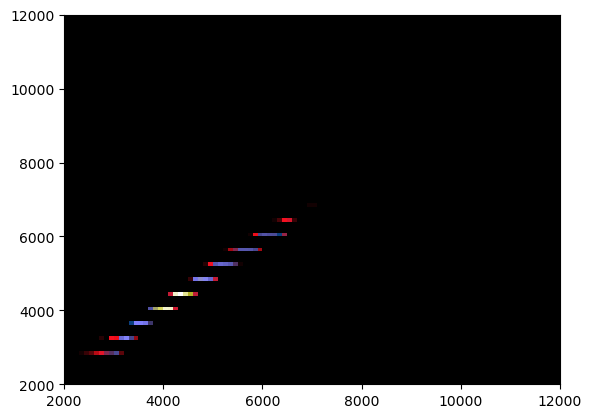

In [339]:
plt.figure()
# plt.scatter(10**training_sample_trilegal['logte'], training_sample_trilegal['Teff_best'], s=10)
# plt.plot([0,50000],[0,50000], c='red')
# plt.xlim(2000,12000)
# plt.ylim(2000,12000)
plt.hist2d(10**training_sample_trilegal['logte'], training_sample_trilegal['Teff_best'], bins=100, range=((2000,12000),(2000,12000)), cmap="gist_stern")

# plt.scatter(training_sample_trilegal['logg'], training_sample_trilegal['logg_best'], s=10)
# plt.hist2d(training_sample_trilegal['logg'], training_sample_trilegal['logg_best'],bins=30)

# plt.scatter(training_sample_trilegal['FeH_best'], training_sample_trilegal['m_h'], s=10)
# plt.hist2d(training_sample_trilegal['FeH_best'], training_sample_trilegal['m_h'],bins=np.linspace(-2.5,0.6,50))
plt.show()

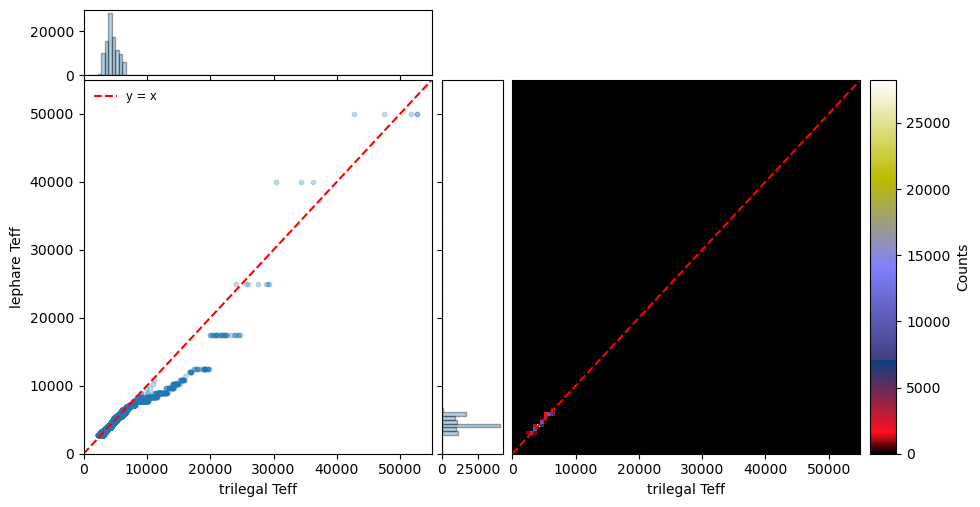

In [340]:
ssp.scatter_vs_hist2D(x=10**training_sample_trilegal['logte'], y=training_sample_trilegal['Teff_best'],
                      deltaz=None, xlabel='trilegal Teff', ylabel='lephare Teff', labels=None,
                      zmax=None, xrange=(0,55000), yrange=(0,55000), cmaps='gist_stern', dline=True)